In [53]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import geopandas as gpd
from matplotlib.patches import Rectangle

In [55]:
county="tarrant"

dependent = pd.read_csv(f"{county}_income_mobility_score.csv")
independent = pd.read_csv(f"{county}_health_composite_score.csv")

dependent['TractFIPS'] = dependent['GEO_ID'].str.replace('1400000US', '', regex=False).astype('int64')

merged = dependent.merge(
    independent[['TractFIPS', 'final_health_composite']],
    on='TractFIPS', how='inner'
)

print(merged.shape)

(1110, 250)


In [56]:
final = merged[['TractFIPS', 'final_income_mobility_composite', 'final_health_composite']].copy()
final['income_mobility_pct'] = final['final_income_mobility_composite'] * 100
final['health_pct'] = final['final_health_composite'] * 100

final.to_csv(f"{county}_bivariate_data.csv", index=False)
final.head()

,TractFIPS,final_income_mobility_composite,final_health_composite,income_mobility_pct,health_pct
0,48201100001,0.419266,0.054955,41.926606,5.495495
1,48201210400,0.198165,0.914414,19.816514,91.441441
2,48201210500,0.211927,0.910811,21.192661,91.081081
3,48201210600,0.378899,0.501802,37.889908,50.180180
4,48201210700,0.489908,0.788739,48.990826,78.873874


In [58]:
tracts = gpd.read_file("../Census_Tract/tl_2025_48_tract.shp")
# change county FIPS number
county_tracts = tracts[tracts['COUNTYFP'] == '201'].copy()
county_tracts['TractFIPS'] = county_tracts['GEOID'].astype('int64')

In [59]:
df = pd.read_csv(f"{county}_bivariate_data.csv")

# Merge geometry with your data
gdf = county_tracts.merge(df, on='TractFIPS', how='inner')
print(gdf.shape)   

(1110, 19)


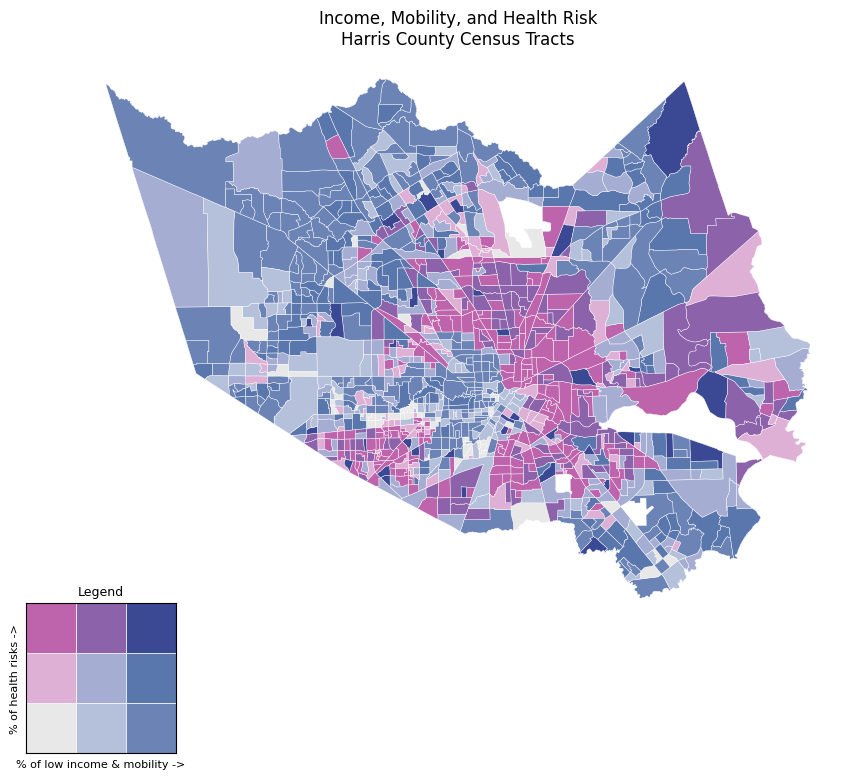

In [60]:
def tercile(x):
    if x <= 33.33: return 1
    elif x <= 66.67: return 2
    else: return 3

gdf["x_class"] = gdf["income_mobility_pct"].apply(tercile)
gdf["y_class"] = gdf["health_pct"].apply(tercile)
gdf["bivar_class"] = gdf["x_class"].astype(str) + "-" + gdf["y_class"].astype(str)

color_map = {
    "1-1": "#e8e8e8", "2-1": "#b5c0da", "3-1": "#6c83b5",   # low need, low→high burden
    "1-2": "#dfb0d6", "2-2": "#a5add3", "3-2": "#5a77ad",
    "1-3": "#be64ac", "2-3": "#8c62aa", "3-3": "#3b4994",   # high need, low→high burden
}
gdf["fill_color"] = gdf["bivar_class"].map(color_map)

fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(color=gdf["fill_color"], edgecolor="white", linewidth=0.3, ax=ax)
ax.set_axis_off()
ax.set_title(f"Income, Mobility, and Health Risk\n{county.title()} County Census Tracts")

legend_ax = fig.add_axes([0.08, 0.08, 0.15, 0.15])  # [left, bottom, width, height] as fraction of figure

grid_colors = [
    ["#e8e8e8", "#b5c0da", "#6c83b5"],   # y_class = 1 (low health burden)
    ["#dfb0d6", "#a5add3", "#5a77ad"],   # y_class = 2
    ["#be64ac", "#8c62aa", "#3b4994"],   # y_class = 3 (high health burden)
]

for row in range(3):
    for col in range(3):
        legend_ax.add_patch(Rectangle((col, row), 1, 1, facecolor=grid_colors[row][col], edgecolor="white", linewidth=0.5))

legend_ax.set_xlim(0, 3)
legend_ax.set_ylim(0, 3)
legend_ax.set_xticks([])
legend_ax.set_yticks([])
legend_ax.set_xlabel("% of low income & mobility ->", fontsize=8)
legend_ax.set_ylabel("% of health risks ->", fontsize=8)
legend_ax.set_title("Legend", fontsize=9)

plt.savefig(f"{county}_bivariate_choropleth.png", dpi=200, bbox_inches="tight")
plt.show()